In [1]:
import pandas as pd
import pybaseball as pb
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import mlbstatsapi 
import scipy.stats as stats
mlb = mlbstatsapi.Mlb()
import json

In [ ]:

# Bootstrap cell — fixes PreToolUse hook deadlock caused by stuck CWD in notebooks/
# Run this cell once, then restart Claude Code session.
import os, pathlib

PROJECT = pathlib.Path(r"C:\Users\gavro\OneDrive\Desktop\sports\mlb")

# 1. Create stub pre_tool_use.py at the path the hook framework resolves to
stub_dir = PROJECT / "notebooks" / ".claude" / "hooks"
stub_dir.mkdir(parents=True, exist_ok=True)
stub = stub_dir / "pre_tool_use.py"
stub.write_text("import sys\nsys.exit(0)\n")
print(f"[1] Created stub hook: {stub}")

# 2. Update settings.json to use absolute paths (permanent fix)
import json
settings_path = PROJECT / ".claude" / "settings.json"
settings = {
  "hooks": {
    "SessionStart": [{"hooks": [{"type": "command", "command": f'python "{PROJECT}\\.claude\\hooks\\session_start.py"'}]}],
    "PreToolUse": [
      {"matcher": "Bash", "hooks": [{"type": "command", "command": f'python "{PROJECT}\\.claude\\hooks\\pre_tool_use.py"'}]},
      {"matcher": "Edit|Write|Create", "hooks": [{"type": "command", "command": f'python "{PROJECT}\\.claude\\hooks\\pre_tool_use.py"'}]}
    ],
    "PostToolUse": [
      {"matcher": "Edit|Write|Create", "hooks": [{"type": "command", "command": f'python "{PROJECT}\\.claude\\hooks\\post_tool_use.py"', "async": True}]}
    ]
  },
  "permissions": {
    "allow": [
      "Bash(python .claude/hooks/*)", "Bash(pytest tests/*)", "Bash(ruff *)",
      "Bash(sqlite3 data/mlb.db *)", "Bash(python -m mlb.*)",
      "Bash(git status)", "Bash(git diff)", "Bash(git log *)",
      "Bash(git add *)", "Bash(git commit *)", "Bash(git checkout *)",
      "Bash(git pull)", "Bash(git push)", "Bash(pip install *)"
    ],
    "deny": ["Bash(rm -rf data/mlb.db)", "Bash(rm -rf data/raw)", "Bash(rm -rf data/models)"]
  }
}
settings_path.write_text(json.dumps(settings, indent=2))
print(f"[2] Updated settings.json with absolute hook paths")

# 3. Write updated MEMORY.md
memory_path = PROJECT / "MEMORY.md"
memory_path.write_text(
"""# Session Memory

## Current Phase
Phase 0 -- Foundation

## Implementation Progress

```
Step 1   pyproject.toml + requirements.txt        [ ]
Step 2   mlb/db.py -- schema + WAL mode           [ ]
Step 3   .claude/ infrastructure                  [x] (pre-built)
Step 4   data/stadiums.py                         [ ]
Step 5   mlb/scraper.py                           [ ]
Step 6   mlb/odds_scraper.py                      [ ]
Step 7   mlb/weather.py                           [x]
Step 8   mlb/kalshi.py                            [x]
Step 9   mlb/polymarket.py                        [x]
Step 10  Initial data load + validation           [x]
Step 11  mlb/features.py                          [x]
Step 12  mlb/elo.py                               [x]
Step 13  tests/unit/                              [x] (test_features.py 17, test_elo.py 18)
Step 14  notebooks/01_data_audit.ipynb            [x]
Step 15  notebooks/02_feature_eda.ipynb           [ ]
Step 16  mlb/model.py                             [ ]
Step 17  mlb/calibration.py                       [ ]
Step 18  notebooks/03_kalshi_market_analysis.ipynb [ ]
Step 19  notebooks/04_model_comparison.ipynb      [ ]
Step 20  mlb/betting.py                           [ ]
Step 21  notebooks/05_betting_simulation.ipynb    [ ]
Step 22  mlb/pipeline.py                          [ ]
Step 23  mlb/live.py                              [ ]
Step 24  .github/workflows/update.yml             [ ]
Step 25  Integration tests + README               [ ]
```

## Last Completed
Step 14 -- notebooks/01_data_audit.ipynb executed, all 7 data quality checks PASS.
Steps 2, 4, 5, 6, 7, 8, 9, 10, 11, 12, partial-13, 14 done.
Elo: 5180 rows, 2022-2024, zero-sum invariant holds, elo_home/elo_away non-null in build_features.

## Known Issues / Notes
- scraper.py bug fixed: _insert_games now also selects home_score in existing query
- days_rest computed in features.py (never populated by scraper)
- precip_prob always NULL for historical weather (archive API limitation)
- Bullpen feature loop is slow O(N*games) -- acceptable for now, optimize later
- OVERDISPERSION CONFIRMED: home_score dispersion=2.14, away_score=2.36 (both >> 1.2)
  -> NegBinom upgrade will be needed in calibration.py
- Park factor correlation with actual scoring: r=0.708 (strong signal)
- 2023 and 2024 game scrapers still running (cut off mid-season in prior session)

## In Progress
Nothing yet.

## Blockers
- None

## Key Decisions Made
- Two-target Poisson regression: predict home_runs (lambda_home) and away_runs (lambda_away) separately
- Poisson convolution for P(over) -- no Normal CDF
- GradientBoostingRegressor(loss='poisson') as primary model
- PoissonRegressor as baseline
- Kalshi totals markets as betting venue; Polymarket as read-only cross-signal
- SBR via sbrscrape for historical odds (2021+)
- Open-Meteo for weather (free, no API key)
- Walk-forward TimeSeriesSplit(n_splits=5, gap=162) -- only valid CV strategy
- 0.25x fractional Kelly, 5% bankroll cap, $0.03 minimum edge
- SQLite WAL mode, single DB file at data/mlb.db
- NegBinom upgrade confirmed needed (dispersion > 1.2 on both targets)

## Open Questions (Resolve in Notebooks)
- Kalshi totals market liquidity -- verify in Notebook 3
- Ensemble vs winner-take-all -- decide after Notebook 4
- Optimal min edge threshold -- sensitivity test in Notebook 5
- Over bias magnitude -- quantify in SBR data
""")
print(f"[3] Updated MEMORY.md")
print("Bootstrap complete. Restart Claude Code to apply absolute hook paths.")


In [2]:
season2025 = mlb.get_scheduled_games_by_date(start_date="2025-04-01", end_date="2025-11-01")
game_pk = [x.game_pk for x in season2025]

In [9]:
game = mlb.get_game(game_id=game_pk[0])
game.model_json_schema()
game.game_data.model_json_schema()

{'$defs': {'BatSide': {'description': 'A class to represent a bat side.\n\nAttributes\n----------\ncode : str\n    Code of the bat side.\ndescription : str\n    Description of the bat side.',
   'properties': {'code': {'title': 'Code', 'type': 'string'},
    'description': {'title': 'Description', 'type': 'string'}},
   'required': ['code', 'description'],
   'title': 'BatSide',
   'type': 'object'},
  'Division': {'description': 'A class to represent a division.\n\nAttributes\n----------\nid : int\n    ID number of the division.\nlink : str\n    API link for the division.\nname : str\n    Name of the division.\nseason : str\n    Current season for the division.\nname_short : str\n    Short name for the division.\nabbreviation : str\n    Abbreviation of the division name.\nleague : League\n    League this division is in.\nsport : Sport\n    Sport this division is in.\nhas_wildcard : bool\n    Whether this league has a wildcard.\nsort_order : int\n    Sort order.\nnum_playoff_teams : in

In [ ]:
runs_scored = [ ]
for gid in game_pk: 
    bs = mlb.get_game_box_score(gid)
    r_away = int(bs['awayBattingTotals']['r'])
    r_home = int(bs['homeBattingTotals']['r'])
    r_total = r_away + r_home
    runs_scored.append(r_total)
    print(r_total)

AttributeError: 'Mlb' object has no attribute 'boxscore_data'

In [17]:
np.mean(runs_scored)

np.float64(8.896114519427403)

In [18]:
np.std(runs_scored)

np.float64(4.57965685250334)

<Axes: ylabel='Density'>

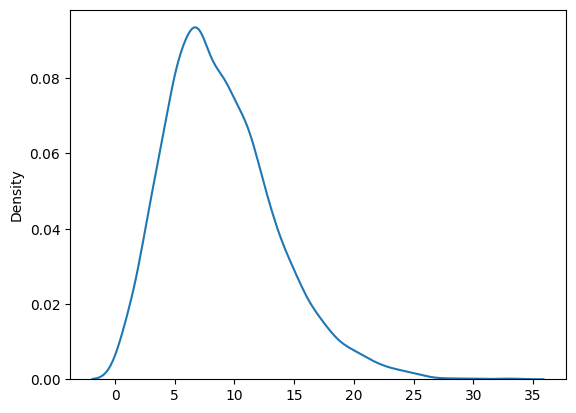

In [15]:
sns.kdeplot(runs_scored)